**Data Preparation**

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
df = pd.read_csv("heart.csv")

In [23]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [24]:
print(df.shape)

(1888, 14)


In [25]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [26]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [27]:
print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalachh      int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [28]:
X = df.drop("target", axis=1)
y = df["target"]

In [29]:
print(X.shape)
print(y.shape)

(1888, 13)
(1888,)


In [30]:
print(df["target"].value_counts())

target
1    977
0    911
Name: count, dtype: int64


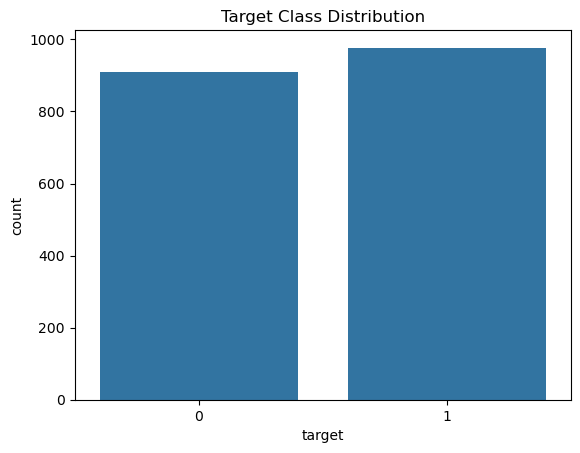

In [31]:
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution")
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
scaler = StandardScaler()

In [35]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1510, 13)
(378, 13)
(1510,)
(378,)


**Baseline Model Development**

In [38]:
def initialize_parameters(n_features):
    
    W = np.zeros((n_features, 1))
    b = 0
    
    return W, b

In [39]:
n_features = X_train.shape[1]

W, b = initialize_parameters(n_features)

print(W.shape)
print(b)

(13, 1)
0


Forward Propagation


In [41]:
def sigmoid(z):
    
    return 1 / (1 + np.exp(-z))

In [42]:
def forward_propagation(X, W, b):
    
    z = np.dot(X, W) + b
    
    y_hat = sigmoid(z)
    
    return y_hat

In [43]:
y_hat = forward_propagation(X_train, W, b)

print(y_hat.shape)
print(y_hat[:5])

(1510, 1)
[[0.5]
 [0.5]
 [0.5]
 [0.5]
 [0.5]]


Loss Function

In [45]:
def compute_loss(y, y_hat):
    
    m = y.shape[0]
    
    y = y.values.reshape(m, 1)
    
    loss = -(1/m) * np.sum(
        y * np.log(y_hat) +
        (1 - y) * np.log(1 - y_hat)
    )
    
    return loss

In [46]:
loss = compute_loss(y_train, y_hat)

print(loss)

0.6931471805599454


In [47]:
def backward_propagation(X, y, y_hat):
    
    m = X.shape[0]
    
    y = y.values.reshape(m, 1)
    
    dz = y_hat - y
    
    dW = (1/m) * np.dot(X.T, dz)
    
    db = (1/m) * np.sum(dz)
    
    return dW, db

In [48]:
def update_parameters(W, b, dW, db, learning_rate):
    
    W = W - learning_rate * dW
    
    b = b - learning_rate * db
    
    return W, b

In [49]:
def train_logistic_regression(X, y, learning_rate=0.01, epochs=1000):
    
    n_features = X.shape[1]
    
    W, b = initialize_parameters(n_features)
    
    loss_history = []
    
    for i in range(epochs):
        
        # Forward propagation
        y_hat = forward_propagation(X, W, b)
        
        # Compute loss
        loss = compute_loss(y, y_hat)
        
        # Backpropagation
        dW, db = backward_propagation(X, y, y_hat)
        
        # Update parameters
        W, b = update_parameters(
            W,
            b,
            dW,
            db,
            learning_rate
        )
        
        # Store loss
        loss_history.append(loss)
        
        # Print loss occasionally
        if i % 100 == 0:
            print(f"Epoch {i}, Loss: {loss}")
    
    return W, b, loss_history

In [50]:
W, b, loss_history = train_logistic_regression(
    X_train,
    y_train,
    learning_rate=0.01,
    epochs=1000
)

Epoch 0, Loss: 0.6931471805599454
Epoch 100, Loss: 0.5802160689936864
Epoch 200, Loss: 0.5377314664801665
Epoch 300, Loss: 0.5178593867757658
Epoch 400, Loss: 0.5070002080893897
Epoch 500, Loss: 0.5004051185716963
Epoch 600, Loss: 0.49609396479633405
Epoch 700, Loss: 0.4931234660122604
Epoch 800, Loss: 0.4909962597747458
Epoch 900, Loss: 0.4894283903511348


Prediction Function

In [52]:
def predict(X, W, b):
    
    y_hat = forward_propagation(X, W, b)
    
    predictions = (y_hat >= 0.5).astype(int)
    
    return predictions
    

In [53]:
y_pred = predict(X_test, W, b)

print(y_pred[:10])

[[0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]]


Evaluation Metrics

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.7063492063492064
Precision: 0.6755555555555556
Recall   : 0.8
F1 Score : 0.7325301204819277


In [56]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[115  73]
 [ 38 152]]


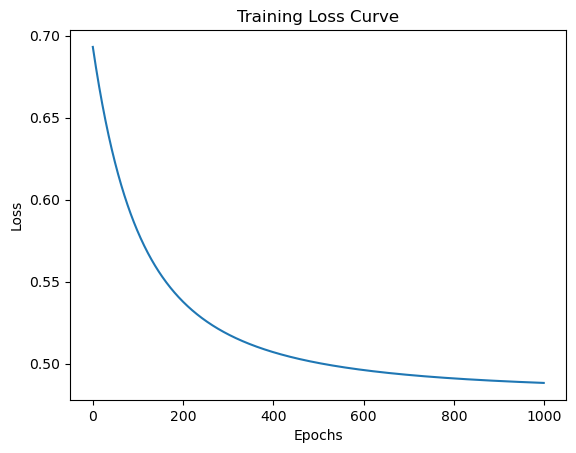

In [57]:
plt.plot(loss_history)

plt.title("Training Loss Curve")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.show()

**Multi-Layer Perceptron Development**

In [59]:
def initialize_mlp_parameters(input_size, hidden1_size, hidden2_size, output_size):
    
    np.random.seed(42)
    
    W1 = np.random.randn(input_size, hidden1_size) * np.sqrt(2 / input_size)
    b1 = np.zeros((1, hidden1_size))
    
    W2 = np.random.randn(hidden1_size, hidden2_size) * np.sqrt(2 / hidden1_size)
    b2 = np.zeros((1, hidden2_size))
    
    W3 = np.random.randn(hidden2_size, output_size) * np.sqrt(2 / hidden2_size)
    b3 = np.zeros((1, output_size))
    
    return W1, b1, W2, b2, W3, b3

In [60]:
def relu(z):
    
    return np.maximum(0, z)

In [61]:
def mlp_forward_propagation(X, W1, b1, W2, b2, W3, b3):
    
    # Layer 1
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    
    # Layer 2
    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)
    
    # Output Layer
    Z3 = np.dot(A2, W3) + b3
    A3 = sigmoid(Z3)
    
    return Z1, A1, Z2, A2, Z3, A3

In [62]:
input_size = X_train.shape[1]

hidden1_size = 16
hidden2_size = 8

output_size = 1

W1, b1, W2, b2, W3, b3 = initialize_mlp_parameters(
    input_size,
    hidden1_size,
    hidden2_size,
    output_size
)

In [63]:
Z1, A1, Z2, A2, Z3, A3 = mlp_forward_propagation(
    X_train,
    W1,
    b1,
    W2,
    b2,
    W3,
    b3
)

In [64]:
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)

print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

print("A3 shape:", A3.shape)

Z1 shape: (1510, 16)
A1 shape: (1510, 16)
Z2 shape: (1510, 8)
A2 shape: (1510, 8)
A3 shape: (1510, 1)


In [65]:
def relu_derivative(z):
    
    return (z > 0).astype(float)

In [66]:
def mlp_backward_propagation(
    X,
    y,
    Z1, A1,
    Z2, A2,
    A3,
    W2,
    W3
):
    
    m = X.shape[0]
    
    y = y.values.reshape(m, 1)
    
    # Output layer error
    dZ3 = A3 - y
    
    dW3 = (1/m) * np.dot(A2.T, dZ3)
    db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)
    
    # Hidden layer 2
    dA2 = np.dot(dZ3, W3.T)
    
    dZ2 = dA2 * relu_derivative(Z2)
    
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    # Hidden layer 1
    dA1 = np.dot(dZ2, W2.T)
    
    dZ1 = dA1 * relu_derivative(Z1)
    
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2, dW3, db3

In [67]:
def update_mlp_parameters(
    W1, b1,
    W2, b2,
    W3, b3,
    dW1, db1,
    dW2, db2,
    dW3, db3,
    learning_rate
):
    
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    
    return W1, b1, W2, b2, W3, b3

In [68]:
def train_mlp(
    X,
    y,
    hidden1_size=16,
    hidden2_size=8,
    learning_rate=0.01,
    epochs=1000
):
    
    input_size = X.shape[1]
    output_size = 1
    
    # Initialize parameters
    W1, b1, W2, b2, W3, b3 = initialize_mlp_parameters(
        input_size,
        hidden1_size,
        hidden2_size,
        output_size
    )
    
    loss_history = []
    
    for epoch in range(epochs):
        
        # Forward propagation
        Z1, A1, Z2, A2, Z3, A3 = mlp_forward_propagation(
            X,
            W1, b1,
            W2, b2,
            W3, b3
        )
        
        # Compute loss
        loss = compute_loss(y, A3)
        
        # Backpropagation
        dW1, db1, dW2, db2, dW3, db3 = mlp_backward_propagation(
            X,
            y,
            Z1, A1,
            Z2, A2,
            A3,
            W2,
            W3
        )
        
        # Update parameters
        W1, b1, W2, b2, W3, b3 = update_mlp_parameters(
            W1, b1,
            W2, b2,
            W3, b3,
            dW1, db1,
            dW2, db2,
            dW3, db3,
            learning_rate
        )
        
        # Store loss
        loss_history.append(loss)
        
        # Print progress
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")
    
    return W1, b1, W2, b2, W3, b3, loss_history

In [69]:
W1, b1, W2, b2, W3, b3, mlp_loss_history = train_mlp(
    X_train,
    y_train,
    hidden1_size=16,
    hidden2_size=8,
    learning_rate=0.01,
    epochs=1000
)

Epoch 0, Loss: 0.7636154596014697
Epoch 100, Loss: 0.6460744698284161
Epoch 200, Loss: 0.5980718402674791
Epoch 300, Loss: 0.5647376277083794
Epoch 400, Loss: 0.5407487517461366
Epoch 500, Loss: 0.5224157698390505
Epoch 600, Loss: 0.5075240503010466
Epoch 700, Loss: 0.494813906540892
Epoch 800, Loss: 0.4848627078014656
Epoch 900, Loss: 0.4760769961273405


In [70]:
def mlp_predict(X, W1, b1, W2, b2, W3, b3):
    
    _, _, _, _, _, A3 = mlp_forward_propagation(
        X,
        W1, b1,
        W2, b2,
        W3, b3
    )
    
    predictions = (A3 >= 0.5).astype(int)
    
    return predictions

In [71]:
mlp_y_pred = mlp_predict(
    X_test,
    W1, b1,
    W2, b2,
    W3, b3
)

**Evaluation and Comparative Analysis**

In [73]:
mlp_accuracy = accuracy_score(y_test, mlp_y_pred)

mlp_precision = precision_score(y_test, mlp_y_pred)

mlp_recall = recall_score(y_test, mlp_y_pred)

mlp_f1 = f1_score(y_test, mlp_y_pred)

In [74]:
print("MLP Accuracy :", mlp_accuracy)

print("MLP Precision:", mlp_precision)

print("MLP Recall   :", mlp_recall)

print("MLP F1 Score :", mlp_f1)

MLP Accuracy : 0.7195767195767195
MLP Precision: 0.6707317073170732
MLP Recall   : 0.868421052631579
MLP F1 Score : 0.7568807339449541


In [75]:
mlp_cm = confusion_matrix(y_test, mlp_y_pred)

print(mlp_cm)

[[107  81]
 [ 25 165]]


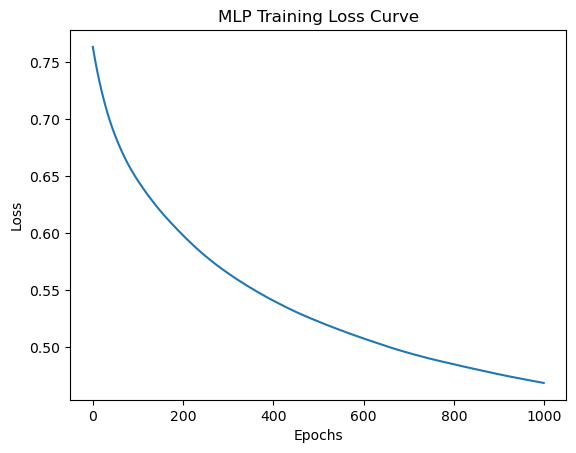

In [76]:
plt.plot(mlp_loss_history)

plt.title("MLP Training Loss Curve")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.show()

In [77]:
import pickle

In [78]:
model_parameters = {
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2,
    "W3": W3,
    "b3": b3
}

In [79]:
with open("heart_disease_mlp.pkl", "wb") as file:
    pickle.dump(model_parameters, file)

In [80]:
import pickle

with open("heart_disease_mlp.pkl", "rb") as file:
    model = pickle.load(file)

print(model.keys())

dict_keys(['W1', 'b1', 'W2', 'b2', 'W3', 'b3'])
